In [1]:
!uv pip install matplotlib transformers 

Using Python 3.14.4 environment at: /home/nico/miniconda3/envs/drp
Checked 2 packages in 35ms


In [2]:
!which jupyter

/home/nico/.local/bin/jupyter


In [3]:
%matplotlib inline
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import clear_output
from ipywidgets import interact
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image

In [4]:
# Helper functions


def fake_pil_image():
    # 1. Create a mock scientific image with shape [1, H, W] containing distinct targets
    np.random.seed(42)
    h, w = 600, 800
    mock_sensor_data = np.zeros((1, h, w))
    y_idx, x_idx = np.indices((h, w))

    # Generate two distinct signal blobs
    mock_sensor_data[0] += 0.8 * np.exp(-((x_idx - 100) ** 2 + (y_idx - 150) ** 2) / (35**2))
    mock_sensor_data[0] += 0.6 * np.exp(-((x_idx - 260) ** 2 + (y_idx - 90) ** 2) / (25**2))
    mock_sensor_data[0] += np.random.normal(0, 0.04, (h, w))  # Sensor noise
    mock_sensor_data = np.clip(mock_sensor_data, 0, 1)
    return pil_from_array(mock_sensor_data)


def pil_from_array(image_array):
    """
    Safely handles [1, H, W] grayscale arrays, passes them through DINOv3,
    and returns perfectly aligned spatial patch features.
    """
    # 1. Handle the [1, H, W] or [H, W] single-channel shape
    image_array = np.squeeze(image_array)
    if len(image_array.shape) != 2:
        raise ValueError(f"Expected a 2D grayscale slice, got shape {image_array.shape}")

    # 2. Convert grayscale values to 0-255 uint8 range
    if image_array.max() <= 1.0:
        image_array = (image_array * 255).astype(np.uint8)
    else:
        image_array = image_array.astype(np.uint8)

    # Expand 1-channel to 3-channels for the visual encoder
    rgb_image = np.stack([image_array] * 3, axis=-1)
    pil_image = Image.fromarray(rgb_image)
    return pil_image


def build_processor(pil_image):
    H, W, C = np.asarray(pil_image).shape
    h_trimmed = 16 * int(H / 16)
    w_trimmed = 16 * int(W / 16)
    # c_trimmed = min(1, C)

    # Create image processor
    processor = AutoImageProcessor.from_pretrained(model_name)
    processor.do_center_crop = True
    # processor.do_resize = False
    # processor.size = {"height": arr.shape[1], "width": arr.shape[2]}
    processor.crop_size = {"height": h_trimmed, "width": w_trimmed}
    processor.size = {"height": h_trimmed, "width": w_trimmed}

    return processor


SIM_QUANTILE = 0.95


def plot_cosine_similarity(x_patch, y_patch):
    # Clear previous image frame to unfreeze sliders
    clear_output(wait=True)

    # Select the query vector
    query_vector = patch_grid[y_patch, x_patch]

    # Dot product calculation for cosine similarity
    _similarity_map = torch.einsum("hwd,d->hw", patch_grid, query_vector).numpy()
    similarity_map = np.where(
        _similarity_map > np.quantile(_similarity_map, SIM_QUANTILE), _similarity_map, 0
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Left view: Uncropped full scene tracking your target coordinates
    ax1.imshow(display_img)
    ax1.set_title(f"DINOv3 Full Input View (Query: X={x_patch}, Y={y_patch})")
    ax1.axis("off")

    # Draw selected patch marker based on 16px blocks
    patch_size = 16
    center_x = (x_patch * patch_size) + (patch_size // 2)
    center_y = (y_patch * patch_size) + (patch_size // 2)
    ax1.plot(
        center_x,
        center_y,
        marker="o",
        color="red",
        markersize=9,
        markeredgecolor="white",
        markeredgewidth=2,
    )

    # Right view: Heatmap with dynamic normalization bounds
    # Removing hardcoded vmin/vmax allows full-spectrum contrast scaling
    im = ax2.imshow(similarity_map, cmap="magma", interpolation="nearest")
    ax2.set_title("DINOv3 Patch Cosine Similarity Heatmap")
    ax2.axis("off")

    cbar = fig.colorbar(im, ax=ax2, fraction=0.036, pad=0.04)
    cbar.set_label("Local Similarity Range", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()


def extract_dinov3_features(pil_image, model, processor, device, max_h=1500, max_w=1500):
    try:
        H, W, C = np.asarray(pil_image).shape
        assert C == 3
        assert max_h >= H
        assert max_w >= W
    except Exception as e:
        raise ValueError(f"Invalid image shape: {np.asarray(pil_image).shape=}") from e
    # 3. Forward pass
    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    last_hidden_state = outputs.last_hidden_state  # (1, Seq_Len, Hidden_Dim)

    # 4. Dynamically isolate spatial tokens
    # DINOv3 uses 1 CLS token + 4 register tokens.
    # At 224x224 with patch_size=16, we get a 14x14 = 196 patch grid.
    patch_size = 16
    target_h = processor.size["height"]
    target_w = processor.size["width"]
    grid_h = target_h // patch_size
    grid_w = target_w // patch_size
    num_spatial_patches = grid_h * grid_w

    # Slice the exact spatial patch tokens from the tail of the sequence
    patch_tokens = last_hidden_state[0, -num_spatial_patches:, :]
    patch_grid = patch_tokens.reshape(grid_h, grid_w, -1)

    # L2 Normalize for robust cosine similarity calculation
    patch_grid_norm = F.normalize(patch_grid, p=2, dim=-1).detach().cpu()

    # Reconstruct the precise image evaluated by the model (ensures flawless alignment)
    model_input_tensor = inputs["pixel_values"][0].detach().cpu()
    mean = torch.tensor(processor.image_mean).view(3, 1, 1)
    std = torch.tensor(processor.image_std).view(3, 1, 1)
    unnormalized_tensor = (model_input_tensor * std) + mean
    display_image = unnormalized_tensor.permute(1, 2, 0).detach().numpy()
    display_image = np.clip(display_image, 0, 1)

    return patch_grid_norm, display_image, grid_h, grid_w

In [5]:
# Load DINOv3 Base with 16x16 patch projection
IMAGE_DIR = Path("images")
model_name = "facebook/dinov3-vitl16-pretrain-lvd1689m"
# model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
print(f"Loading DINOv3 checkpoint: {model_name}...")

model = AutoModel.from_pretrained(model_name)

# Move model to accelerator
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"
model = model.to(device)
model.eval()
print(f"DINOv3 loaded onto {device}!")

Loading DINOv3 checkpoint: facebook/dinov3-vitl16-pretrain-lvd1689m...


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

DINOv3 loaded onto cuda!


### Visualize PIL Image

In [6]:
# 1. Load PIL Image


# img_idx = 3
# imgs = [
#     "mit-visit-day-nrw.png",
#     "sdr.png",
#     "cloudy.png",
#     "artemis.png",
# ]
# pil_image = Image.open(IMAGE_DIR / imgs[img_idx])
# arr = np.array(pil_image)
# arr = arr[:, :, :3]

# pil_image = Image.fromarray(arr)

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
pil_image = load_image(url)


# 2. Extract DINO v3 patch grid
processor = build_processor(pil_image)
patch_grid, display_img, grid_h, grid_w = extract_dinov3_features(
    pil_image, model, processor, device, max_w=1800
)

In [7]:
SIM_QUANTILE = 0.0
# 3. Fire up the interactive environment
interact(
    plot_cosine_similarity,
    x_patch=widgets.IntSlider(
        min=0, max=grid_w - 1, step=1, value=grid_w // 2, description="X (Col)"
    ),
    y_patch=widgets.IntSlider(
        min=0, max=grid_h - 1, step=1, value=grid_h // 2, description="Y (Row)"
    ),
);

interactive(children=(IntSlider(value=30, description='X (Col)', max=59), IntSlider(value=21, description='Y (…

### Visualize Image Array

### Zarr Dataset - cloud detection

In [8]:
%load_ext autoreload
%autoreload 2

import os

# Load .env if present
from pathlib import Path

# Editable install (uv sync) makes panoseti_analysis importable — no path hacks.
from panoseti_analysis.paths import REPO_ROOT

_env_file = REPO_ROOT / ".env"
if _env_file.exists():
    for line in _env_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, v = line.split("=", 1)
            os.environ.setdefault(k.strip(), v.strip())
    print("Loaded .env")

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray as xr
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, precision_recall_curve

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print(f"PyTorch {torch.__version__}, CUDA available: {torch.cuda.is_available()}")

Loaded .env
PyTorch 2.12.0+cu130, CUDA available: True


In [9]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# REPO_ROOT is imported from panoseti_analysis.paths (see imports cell)
LABELS_ZIP = REPO_ROOT / "assets/models/cloud-detection-training/training-labels.zip"
DATA_ZIP = REPO_ROOT / "assets/models/cloud-detection-training/training-data-batch.zip"
BEEGFS_ROOT = Path("/mnt/beegfs/panoseti_analysis")

# Batch extraction: use local NVMe SSD to avoid BeeGFS small-file overhead.
# The training-data-batch.zip unpacks to thousands of small .npy files; BeeGFS
# (parallel FS) has high metadata overhead for many small files — use local disk.
# CACHE_ZARR stays on the shared FS so training workers on any node can read it.
LOCAL_SCRATCH = Path("/local/scratch") if Path("/local/scratch").exists() else Path("/tmp")
EXTRACT_DIR = LOCAL_SCRATCH / "panoseti_cache"

CACHE_ZARR = REPO_ROOT / "ml/cloud-detection/cache/cloud_features_legacy.zarr"
OUT_DIR = REPO_ROOT / "ml/cloud-detection/models"
RECIPE_PATH = REPO_ROOT / "recipes/ml/cloud_v1.yml"

# ── Training options ──────────────────────────────────────────────────────────
BATCH_IDS = list(range(8))  # batches 0–7 (all available in the zip)
EPOCHS = 50  # set lower (e.g., 5) for a quick smoke test
WANDB_PROJECT = "panoseti-cloud-detection"  # set to None to disable W&B

print(f"Labels zip  : {LABELS_ZIP.exists()}")
print(f"Data zip    : {DATA_ZIP.exists()}, size={DATA_ZIP.stat().st_size / 1e6:.0f}MB")
print(f"Local scratch: {LOCAL_SCRATCH}  (extraction goes here)")
print(f"Cache Zarr  : {CACHE_ZARR.exists()} (will build if missing)")
print(f"Output dir  : {OUT_DIR}")
print(f"Recipe      : {RECIPE_PATH.exists()}")

Labels zip  : True
Data zip    : True, size=599MB
Local scratch: /tmp  (extraction goes here)
Cache Zarr  : True (will build if missing)
Output dir  : /home/nico/panoseti_analysis/ml/cloud-detection/models
Recipe      : True


In [10]:
import logging

from panoseti_analysis.adapters.cloud.prep_legacy import build_legacy_feature_cache

logging.basicConfig(level=logging.INFO, format="%(message)s")

if CACHE_ZARR.exists():
    print(f"Cache already exists: {CACHE_ZARR}")
    print("Delete it to force rebuild.")
else:
    print(f"Building feature cache from {len(BATCH_IDS)} batches…")
    build_legacy_feature_cache(
        labels_zip=LABELS_ZIP,
        data_zip=DATA_ZIP,
        extract_dir=EXTRACT_DIR,
        out_path=CACHE_ZARR,
        batch_ids=BATCH_IDS,
        skip_unsure=True,
        recipe_path=RECIPE_PATH,
    )
    print("Done.")

Cache already exists: /home/nico/panoseti_analysis/ml/cloud-detection/cache/cloud_features_legacy.zarr
Delete it to force rebuild.


In [11]:
ds = xr.open_zarr(CACHE_ZARR, consolidated=False)
X_all = ds["X"].values.astype(np.float32)  # (N, 2, 32, 32)
y_all = ds["label"].values.astype(np.int64)  # (N,)
split = ds["split"].values  # (N,) str
batch_id = ds["batch_id"].values

N = len(y_all)
print(f"Dataset: {N:,} samples, {X_all.shape[1]} channels, {X_all.shape[2]}×{X_all.shape[3]} px")
print(f"  clear (0): {(y_all == 0).sum():,}  cloudy (1): {(y_all == 1).sum():,}")
print(
    f"  train: {(split == 'train').sum():,}  val: {(split == 'val').sum():,}  test: {(split == 'test').sum():,}"
)
print(f"  batch IDs: {sorted(set(batch_id.tolist()))}")

Dataset: 8,799 samples, 2 channels, 32×32 px
  clear (0): 3,955  cloudy (1): 4,844
  train: 6,601  val: 879  test: 1,319
  batch IDs: [0, 1, 2, 3, 4, 5, 6, 7]


In [12]:
X_all[0]

array([[[ 4.0715246,  5.146627 ,  6.5920334, ...,  7.3536015,
          6.5920334,  5.146627 ],
        [ 4.9647846,  3.3057725,  5.9338813, ...,  5.2885504,
          6.807421 ,  8.01158  ],
        [ 4.666195 ,  5.2040114,  3.854135 , ...,  5.149543 ,
          3.6703677,  8.214521 ],
        ...,
        [ 6.087297 ,  7.526896 ,  4.403889 , ...,  8.611123 ,
          4.0876613,  7.7177706],
        [ 4.666195 ,  8.214521 ,  3.6703677, ...,  6.0858464,
          3.854135 ,  5.2040114],
        [ 4.9647846,  8.01158  ,  6.807421 , ...,  6.6382823,
          5.9338813,  3.3057725]],

       [[17.56894  , 17.109938 , 15.636886 , ..., 14.2466135,
         15.636886 , 17.109938 ],
        [14.37624  , 10.700052 , 13.157258 , ..., 13.865568 ,
         16.49319  , 18.139494 ],
        [14.815861 ,  9.926821 , 11.129727 , ..., 15.43135  ,
         16.101473 , 14.248897 ],
        ...,
        [16.59598  , 13.106603 , 15.597224 , ..., 14.097978 ,
         13.557218 , 14.008555 ],
        [14.

In [14]:
X_all[0][0].shape

(32, 32)

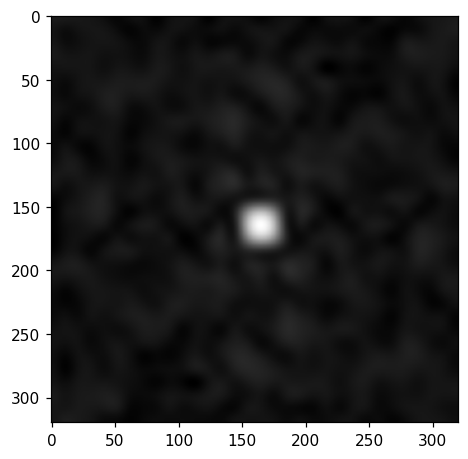

In [23]:
from scipy.ndimage import zoom

# data = np.load(IMAGE_DIR / pano_npys[pano_id])
data = X_all[0][1]
data_zoom = zoom(data, zoom=10, order=3)
# pil_from_array(data)
# plt.imshow(data)
# 1a. normalize
# data = np.log(data)
eps = 1e-9
data_up = data_zoom - np.min(data_zoom) + eps
# data_up = np.log(data_up)
data_norm = data_up / np.max(data_up)
# data_norm = np.exp(data_norm)
# q = np.quantile(data_norm, 0.1)
# data_thresh = np.where(data_norm > q, data_norm, 0)

# 1 . convert to PIL image

data_expanded = np.expand_dims(data_norm, axis=0)
pil_image = pil_from_array(data_expanded)
plt.imshow(np.asarray(pil_image))

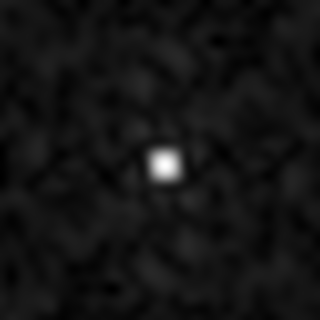

In [24]:
pil_image

In [27]:
# # 2. Extract DINO v3 patch grid
# processor = build_processor(pil_image)
patch_grid, display_img, grid_h, grid_w = extract_dinov3_features(
    pil_image, model, processor, device, max_w=1800
)

In [28]:
# 3. Fire up the interactive environment
SIM_QUANTILE = 0.0
interact(
    plot_cosine_similarity,
    x_patch=widgets.IntSlider(
        min=0, max=grid_w - 1, step=1, value=grid_w // 2, description="X (Col)"
    ),
    y_patch=widgets.IntSlider(
        min=0, max=grid_h - 1, step=1, value=grid_h // 2, description="Y (Row)"
    ),
);

interactive(children=(IntSlider(value=10, description='X (Col)', max=19), IntSlider(value=10, description='Y (…